# IMDb Spoiler Detection using Natural Language Processing

This project aims to classify IMDb user reviews as spoiler or non-spoiler using Natural Language Processing techniques. The main pipeline includes text preprocessing, TF-IDF feature extraction, machine learning model training, and performance evaluation using classification metrics.

## Data & Libraries

In [28]:
# ================================
# Libraries & Setup
# ================================

import os
import json
import re
import string
import time
import shutil
import subprocess
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import joblib

from tqdm.auto import tqdm
from dotenv import load_dotenv
from scipy import sparse

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# Download NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

# Setup
warnings.filterwarnings("ignore")
tqdm.pandas()

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

# Keep negation words because they are important in sentiment/spoiler context
negation_words = {
    "no", "not", "nor", "never",
    "don't", "didn't", "isn't", "wasn't",
    "won't", "can't", "couldn't", "shouldn't"
}

stop_words = stop_words - negation_words

print("Libraries loaded successfully.")

Libraries loaded successfully.


[nltk_data] Downloading package punkt to C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ideapad Gaming
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_

In [29]:
# ================================
# Get Data
# ================================

env_path = Path(".env")
load_dotenv(env_path)

os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

dataset_dir = Path("data/imdb_spoiler_dataset")
cache_dir = Path("data/cache")

dataset_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

reviews_path = dataset_dir / "IMDB_reviews.json"
raw_cache_path = cache_dir / "df_raw.pkl"

# Download dataset only if IMDB_reviews.json does not exist
if not reviews_path.exists():
    print("Dataset not found. Downloading from Kaggle...")

    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "rmisra/imdb-spoiler-dataset",
            "-p",
            str(dataset_dir),
            "--unzip"
        ],
        check=True
    )

    print("Download completed.")
else:
    print("Dataset already exists. Using local data.")

# Load dataset from cache if available
if raw_cache_path.exists():
    print("Loading dataset from cache...")
    df = pd.read_pickle(raw_cache_path)

else:
    print("Loading dataset from JSON...")

    data = []

    with open(reviews_path, "r", encoding="utf-8") as file:
        for line in file:
            data.append(json.loads(line))

    df = pd.DataFrame(data)
    df = df[["review_text", "is_spoiler"]]
    df["is_spoiler"] = df["is_spoiler"].astype(int)

    df.to_pickle(raw_cache_path)
    print("Dataset saved to cache.")

df.head()

Dataset already exists. Using local data.
Loading dataset from cache...


,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,The Shawshank Redemption is without a doubt on...,1
2,I believe that this film is the best story eve...,1
3,"**Yes, there are SPOILERS here**This film has ...",1
4,At the heart of this extraordinary movie is a ...,1


## Exploratory Data Analysis

In [30]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["is_spoiler"].value_counts())

print("\nLabel proportion:")
print(df["is_spoiler"].value_counts(normalize=True))

df.head()

Dataset shape: (573913, 2)

Missing values:
review_text    0
is_spoiler     0
dtype: int64

Label distribution:
is_spoiler
0    422989
1    150924
Name: count, dtype: int64

Label proportion:
is_spoiler
0    0.737026
1    0.262974
Name: proportion, dtype: float64


,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,The Shawshank Redemption is without a doubt on...,1
2,I believe that this film is the best story eve...,1
3,"**Yes, there are SPOILERS here**This film has ...",1
4,At the heart of this extraordinary movie is a ...,1


Dataset asli memiliki distribusi kelas yang tidak seimbang, di mana jumlah review non-spoiler lebih banyak dibandingkan review spoiler. Oleh karena itu, dilakukan balancing agar model tidak terlalu bias terhadap kelas mayoritas.

In [31]:
# ================================
# Balance Dataset
# ================================

sample_size = 20000
balanced_cache_path = cache_dir / f"df_balanced_{sample_size}_each.pkl"

if balanced_cache_path.exists():
    print("Loading balanced dataset from cache...")
    df_balanced = pd.read_pickle(balanced_cache_path)

else:
    print("Creating balanced dataset...")

    spoiler_df = df[df["is_spoiler"] == True].sample(n=sample_size, random_state=42)
    non_spoiler_df = df[df["is_spoiler"] == False].sample(n=sample_size, random_state=42)

    df_balanced = (
        pd.concat([spoiler_df, non_spoiler_df])
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

    df_balanced.to_pickle(balanced_cache_path)
    print("Balanced dataset saved to cache.")

print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced["is_spoiler"].value_counts())

df_balanced.head()

Creating balanced dataset...
Balanced dataset saved to cache.
Balanced dataset shape: (40000, 2)
is_spoiler
0    20000
1    20000
Name: count, dtype: int64


,review_text,is_spoiler
0,Attended with husband and kids who also really...,0
1,Possible SpoilersHaving seen `The Professional...,1
2,I found it interesting from beginning to end. ...,0
3,"""Die Hard 2"" is the first sequel to one of the...",1
4,"(((((((((SHUDDER))))))))) Truly, one of the mo...",0


Dataset yang digunakan pada eksperimen ini adalah data hasil balancing sebanyak 400.000 review, terdiri dari 20.000 review spoiler dan 20.000 review non-spoiler.

## Preprocessing

In [32]:
# ================================
# Text Preprocessing
# ================================

preprocessed_cache_path = cache_dir / f"df_preprocessed_{sample_size}_each.pkl"

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)

    tokens = [
        token for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return " ".join(tokens)

if preprocessed_cache_path.exists():
    print("Loading preprocessed dataset from cache...")
    df_balanced = pd.read_pickle(preprocessed_cache_path)

else:
    print("Preprocessing text data...")

    df_balanced["clean_review_text"] = df_balanced["review_text"].progress_apply(preprocess_text)

    df_balanced.to_pickle(preprocessed_cache_path)
    print("Preprocessed dataset saved to cache.")

print("Preprocessing completed.")
df_balanced[["review_text", "clean_review_text", "is_spoiler"]].head()

Preprocessing text data...


100%|██████████| 40000/40000 [00:45<00:00, 881.72it/s]


Preprocessed dataset saved to cache.
Preprocessing completed.


,review_text,clean_review_text,is_spoiler
0,Attended with husband and kids who also really...,attended husband kid also really enjoyed uplif...,0
1,Possible SpoilersHaving seen `The Professional...,possible spoilershaving seen professional enou...,1
2,I found it interesting from beginning to end. ...,found interesting beginning end usually long m...,0
3,"""Die Hard 2"" is the first sequel to one of the...",die hard first sequel one best iconic action f...,1
4,"(((((((((SHUDDER))))))))) Truly, one of the mo...",shudder truly one pathetic movie ive conned wa...,0


Tahap preprocessing dilakukan untuk membersihkan teks sebelum masuk ke model. Proses yang dilakukan meliputi lowercasing, penghapusan tanda baca, penghapusan angka, tokenization, stopword removal, dan lemmatization.

In [33]:
sample_index = 0

print("Original Review:")
print(df_balanced.loc[sample_index, "review_text"])

print("\nCleaned Review:")
print(df_balanced.loc[sample_index, "clean_review_text"])

print("\nBalanced dataset shape:", df_balanced.shape)
print(df_balanced["is_spoiler"].value_counts())

df_balanced.head()

Original Review:
Attended with husband and kids who also really enjoyed it. Very uplifting movie/ musical. Would definitely watch again and will likely get on dvd. Surprised by negative reviews. Happy to recommend!

Cleaned Review:
attended husband kid also really enjoyed uplifting movie musical would definitely watch likely get dvd surprised negative review happy recommend

Balanced dataset shape: (40000, 3)
is_spoiler
0    20000
1    20000
Name: count, dtype: int64


,review_text,is_spoiler,clean_review_text
0,Attended with husband and kids who also really...,0,attended husband kid also really enjoyed uplif...
1,Possible SpoilersHaving seen `The Professional...,1,possible spoilershaving seen professional enou...
2,I found it interesting from beginning to end. ...,0,found interesting beginning end usually long m...
3,"""Die Hard 2"" is the first sequel to one of the...",1,die hard first sequel one best iconic action f...
4,"(((((((((SHUDDER))))))))) Truly, one of the mo...",0,shudder truly one pathetic movie ive conned wa...


## Data Splitting

In [34]:
X = df_balanced['clean_review_text']
y = df_balanced['is_spoiler'].astype(int)

# test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train & validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

## Feature Extraction

In [35]:
# ================================
# Feature Extraction with TF-IDF
# ================================

tfidf_cache_dir = cache_dir / "tfidf_features"
tfidf_cache_dir.mkdir(parents=True, exist_ok=True)

tfidf_vectorizer_path = tfidf_cache_dir / "tfidf_vectorizer.joblib"
x_train_path = tfidf_cache_dir / "X_train_tfidf.npz"
x_val_path = tfidf_cache_dir / "X_val_tfidf.npz"
x_test_path = tfidf_cache_dir / "X_test_tfidf.npz"

if (
    tfidf_vectorizer_path.exists()
    and x_train_path.exists()
    and x_val_path.exists()
    and x_test_path.exists()
):
    print("Loading TF-IDF features from cache...")

    tfidf_vectorizer = joblib.load(tfidf_vectorizer_path)
    X_train_tfidf = sparse.load_npz(x_train_path)
    X_val_tfidf = sparse.load_npz(x_val_path)
    X_test_tfidf = sparse.load_npz(x_test_path)

else:
    print("Extracting TF-IDF features...")

    tfidf_vectorizer = TfidfVectorizer(
        max_features=80000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    X_train_tfidf = tfidf_vectorizer.fit_transform(
        tqdm(X_train.tolist(), desc="Fitting TF-IDF on Train Data", unit="review")
    )

    X_val_tfidf = tfidf_vectorizer.transform(
        tqdm(X_val.tolist(), desc="Transforming Validation Data", unit="review")
    )

    X_test_tfidf = tfidf_vectorizer.transform(
        tqdm(X_test.tolist(), desc="Transforming Test Data", unit="review")
    )

    joblib.dump(tfidf_vectorizer, tfidf_vectorizer_path)
    sparse.save_npz(x_train_path, X_train_tfidf)
    sparse.save_npz(x_val_path, X_val_tfidf)
    sparse.save_npz(x_test_path, X_test_tfidf)

    print("TF-IDF features saved to cache.")

print("TF-IDF feature extraction completed.")
print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Extracting TF-IDF features...


Transforming Test Data: 100%|██████████| 8000/8000 [00:01<00:00, 4903.90review/s]


TF-IDF features saved to cache.
TF-IDF feature extraction completed.
Train shape: (25600, 80000)
Validation shape: (6400, 80000)
Test shape: (8000, 80000)


## Modelling

In [36]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(
        C=0.1,
        max_iter=3000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=50,
        random_state=42,
        n_jobs=-1
    )
}

results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "Threshold": []
}

best_thresholds = {}
model_objects = {}
model_predictions = {}

print("Mulai melatih model Machine Learning...")

for name, model in models.items():
    print(f"--> Sedang melatih {name}...")

    model.fit(X_train_tfidf, y_train)

    if name == "Logistic Regression":
        val_prob = model.predict_proba(X_val_tfidf)[:, 1]

        threshold_results = []

        for threshold in np.arange(0.30, 0.71, 0.01):
            val_pred = (val_prob >= threshold).astype(int)

            threshold_results.append({
                "threshold": threshold,
                "f1_score": f1_score(y_val, val_pred),
                "precision": precision_score(y_val, val_pred),
                "recall": recall_score(y_val, val_pred)
            })

        threshold_df = pd.DataFrame(threshold_results)

        best_threshold = threshold_df.sort_values(
            by="f1_score",
            ascending=False
        ).iloc[0]["threshold"]

        print(f"   Best threshold: {best_threshold:.2f}")

        test_prob = model.predict_proba(X_test_tfidf)[:, 1]
        y_pred = (test_prob >= best_threshold).astype(int)

        best_thresholds[name] = best_threshold

    else:
        y_pred = model.predict(X_test_tfidf)
        best_threshold = None
        best_thresholds[name] = None

    model_objects[name] = model
    model_predictions[name] = y_pred

    results["Model"].append(name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["F1-Score"].append(f1_score(y_test, y_pred))
    results["Threshold"].append(best_threshold)

print("Pelatihan selesai!\n")

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-Score", ascending=False)

Mulai melatih model Machine Learning...
--> Sedang melatih Logistic Regression...
   Best threshold: 0.39
--> Sedang melatih Naive Bayes...
--> Sedang melatih Linear SVC...
--> Sedang melatih Random Forest...
Pelatihan selesai!



,Model,Accuracy,Precision,Recall,F1-Score,Threshold
0,Logistic Regression,0.658125,0.614854,0.84650,0.712317,0.39
1,Naive Bayes,0.655750,0.632553,0.74325,0.683448,NaN
2,Linear SVC,0.688000,0.697687,0.66350,0.680164,NaN
3,Random Forest,0.654250,0.654250,0.65425,0.654250,NaN


Threshold tuning dilakukan dengan mencari nilai threshold terbaik berdasarkan F1-score pada validation set. Hal ini dilakukan karena threshold default 0.5 belum tentu memberikan keseimbangan terbaik antara precision dan recall.

## Model Evaluation

Berdasarkan hasil evaluasi, Logistic Regression memperoleh F1-score tertinggi dibandingkan Multinomial Naive Bayes. Oleh karena itu, Logistic Regression dipilih sebagai final model dalam sistem deteksi spoiler ini.

In [37]:
# ================================
# Select Best Model
# ================================

best_result = results_df.sort_values(by="Recall", ascending=False).iloc[0]

best_model_name = best_result["Model"]
best_model = model_objects[best_model_name]
best_pred = model_predictions[best_model_name]
best_threshold = best_thresholds[best_model_name]

print("Best Model:", best_model_name)
print("Best Recall:", best_result["Recall"])
print("Best Threshold:", best_threshold)

Best Model: Logistic Regression
Best Recall: 0.8465
Best Threshold: 0.39000000000000007


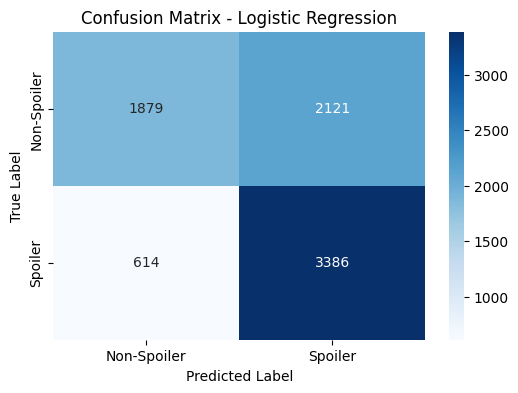

In [38]:
# ================================
# Confusion Matrix of Best Model
# ================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Spoiler", "Spoiler"],
    yticklabels=["Non-Spoiler", "Spoiler"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Berdasarkan confusion matrix, model masih kurang baik dalam menebak review non-spoiler secara tepat karena cukup banyak review non-spoiler yang diprediksi sebagai spoiler. Namun, kondisi ini masih dapat diterima dalam konteks spoiler detection, karena kesalahan yang lebih berisiko adalah ketika review spoiler diprediksi sebagai non-spoiler. Jika hal tersebut terjadi, pengguna dapat melihat spoiler sebelum menonton film.

In [39]:
# ================================
# Classification Report of Best Model
# ================================

print(classification_report(
    y_test,
    best_pred,
    target_names=["Non-Spoiler", "Spoiler"]
))

              precision    recall  f1-score   support

 Non-Spoiler       0.75      0.47      0.58      4000
     Spoiler       0.61      0.85      0.71      4000

    accuracy                           0.66      8000
   macro avg       0.68      0.66      0.65      8000
weighted avg       0.68      0.66      0.65      8000



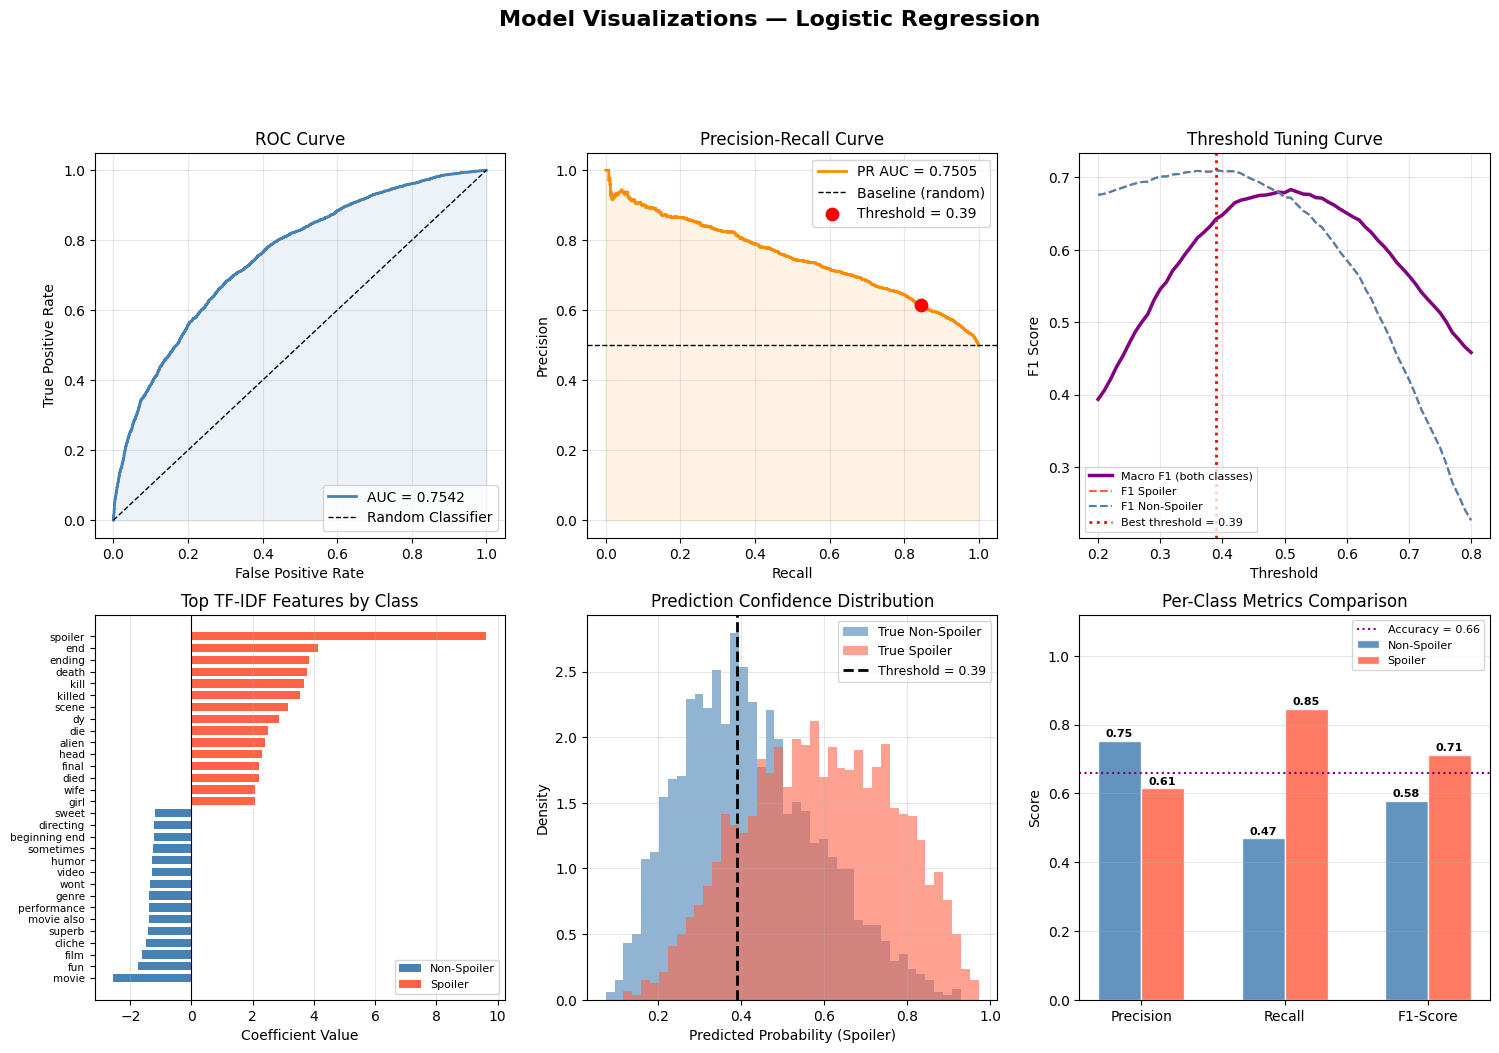

Visualizations saved to best_model_visualizations.png


In [43]:
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f"Model Visualizations — {best_model_name}", fontsize=16, fontweight='bold', y=1.01)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
if hasattr(best_model, "predict_proba"):
    test_prob = best_model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax1.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'predict_proba\nnot available\nfor this model',
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('ROC Curve')

# ── 2. Precision-Recall Curve ─────────────────────────────────────────────────
ax2 = axes[0, 1]
if hasattr(best_model, "predict_proba"):
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, test_prob)
    pr_auc = auc(recall_arr, precision_arr)
    ax2.plot(recall_arr, precision_arr, color='darkorange', lw=2, label=f'PR AUC = {pr_auc:.4f}')
    ax2.fill_between(recall_arr, precision_arr, alpha=0.1, color='darkorange')
    ax2.axhline(y=0.5, color='k', linestyle='--', lw=1, label='Baseline (random)')
    if best_threshold is not None:
        pred_at_thr = (test_prob >= best_threshold).astype(int)
        p_point = precision_score(y_test, pred_at_thr)
        r_point = recall_score(y_test, pred_at_thr)
        ax2.scatter([r_point], [p_point], color='red', zorder=5, s=80,
                    label=f'Threshold = {best_threshold:.2f}')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'predict_proba\nnot available\nfor this model',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Precision-Recall Curve')

# ── 3. Threshold Tuning (Macro F1 vs Threshold) ───────────────────────────────
ax3 = axes[0, 2]
if hasattr(best_model, "predict_proba"):
    val_prob_vis = best_model.predict_proba(X_val_tfidf)[:, 1]
    thr_range = np.arange(0.20, 0.80, 0.01)
    f1_macros, f1_spoilers, f1_nonspoilers = [], [], []

    for thr in thr_range:
        vp = (val_prob_vis >= thr).astype(int)
        f1_macros.append(f1_score(y_val, vp, average='macro'))
        f1_spoilers.append(f1_score(y_val, vp, labels=[1], average='binary'))
        f1_nonspoilers.append(f1_score(y_val, vp, labels=[0], average='binary'))

    ax3.plot(thr_range, f1_macros, label='Macro F1 (both classes)', lw=2.5, color='purple')
    ax3.plot(thr_range, f1_spoilers, label='F1 Spoiler', linestyle='--', color='tomato', lw=1.5)
    ax3.plot(thr_range, f1_nonspoilers, label='F1 Non-Spoiler', linestyle='--', color='steelblue', lw=1.5)
    if best_threshold is not None:
        ax3.axvline(x=best_threshold, color='red', linestyle=':', lw=2,
                    label=f'Best threshold = {best_threshold:.2f}')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('F1 Score')
    ax3.set_title('Threshold Tuning Curve')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Threshold tuning\nnot applicable', ha='center',
             va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Threshold Tuning Curve')

# ── 4. Top TF-IDF Features per Class ─────────────────────────────────────────
ax4 = axes[1, 0]
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

if hasattr(best_model, "coef_"):
    coefs = best_model.coef_[0]
    top_n = 15

    top_spoiler_idx = np.argsort(coefs)[-top_n:][::-1]
    top_nonspoiler_idx = np.argsort(coefs)[:top_n]

    combined_features = (
        list(feature_names[top_nonspoiler_idx]) +
        list(feature_names[top_spoiler_idx])
    )
    combined_coefs = (
        list(coefs[top_nonspoiler_idx]) +
        list(coefs[top_spoiler_idx])
    )
    combined_colors = (
        ['steelblue'] * top_n +
        ['tomato'] * top_n
    )

    sorted_idx = np.argsort(combined_coefs)
    sorted_features = [combined_features[i] for i in sorted_idx]
    sorted_coefs = [combined_coefs[i] for i in sorted_idx]
    sorted_colors = [combined_colors[i] for i in sorted_idx]

    bars = ax4.barh(range(len(sorted_features)), sorted_coefs,
                    color=sorted_colors, edgecolor='none', height=0.7)
    ax4.set_yticks(range(len(sorted_features)))
    ax4.set_yticklabels(sorted_features, fontsize=7.5)
    ax4.axvline(x=0, color='black', linewidth=0.8)
    ax4.set_xlabel('Coefficient Value')
    ax4.set_title('Top TF-IDF Features by Class')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', label='Non-Spoiler'),
                       Patch(facecolor='tomato', label='Spoiler')]
    ax4.legend(handles=legend_elements, loc='lower right', fontsize=8)
    ax4.grid(True, axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'coef_ not available\nfor this model',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('Top TF-IDF Features by Class')

# ── 5. Prediction Confidence Distribution ────────────────────────────────────
ax5 = axes[1, 1]
if hasattr(best_model, "predict_proba"):
    probs_all = best_model.predict_proba(X_test_tfidf)[:, 1]
    probs_spoiler = probs_all[y_test == 1]
    probs_nonspoiler = probs_all[y_test == 0]

    ax5.hist(probs_nonspoiler, bins=40, alpha=0.6, color='steelblue',
             label='True Non-Spoiler', density=True)
    ax5.hist(probs_spoiler, bins=40, alpha=0.6, color='tomato',
             label='True Spoiler', density=True)
    if best_threshold is not None:
        ax5.axvline(x=best_threshold, color='black', linestyle='--', lw=2,
                    label=f'Threshold = {best_threshold:.2f}')
    ax5.set_xlabel('Predicted Probability (Spoiler)')
    ax5.set_ylabel('Density')
    ax5.set_title('Prediction Confidence Distribution')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'predict_proba\nnot available\nfor this model',
             ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.set_title('Prediction Confidence Distribution')

# ── 6. Per-Class Metrics Comparison ──────────────────────────────────────────
ax6 = axes[1, 2]
report = classification_report(y_test, best_pred, target_names=['Non-Spoiler', 'Spoiler'],
                                output_dict=True)

classes = ['Non-Spoiler', 'Spoiler']
metrics_names = ['precision', 'recall', 'f1-score']
x = np.arange(len(metrics_names))
width = 0.3
colors_cls = ['steelblue', 'tomato']

for i, cls in enumerate(classes):
    vals = [report[cls][m] for m in metrics_names]
    bars = ax6.bar(x + i * width, vals, width, label=cls,
                   color=colors_cls[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax6.set_xticks(x + width / 2)
ax6.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
ax6.set_ylim(0, 1.12)
ax6.set_ylabel('Score')
ax6.set_title('Per-Class Metrics Comparison')
ax6.legend()
ax6.grid(True, axis='y', alpha=0.3)
ax6.axhline(y=report['accuracy'], color='purple', linestyle=':', lw=1.5,
            label=f'Accuracy = {report["accuracy"]:.2f}')
ax6.legend(fontsize=8)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

plt.savefig(
    figure_dir / "best_model_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("Visualizations saved to best_model_visualizations.png")

## Manual Prediction Testing

In [ ]:
# ================================
# Spoiler Prediction Function
# ================================

def predict_spoiler(review):
    clean_review = preprocess_text(review)
    review_tfidf = tfidf_vectorizer.transform([clean_review])

    threshold_used = 0.5 if best_threshold is None else best_threshold

    print(f"sample_review = {review}")

    if hasattr(best_model, "predict_proba"):
        probability = best_model.predict_proba(review_tfidf)[0]

        non_spoiler_probability = probability[0] * 100
        spoiler_probability = probability[1] * 100

        prediction = 1 if probability[1] >= threshold_used else 0
        label = "spoiler" if prediction == 1 else "bukan spoiler"

        print(f"Model yakin {spoiler_probability:.2f}% bahwa sample_review adalah spoiler")
        print(f"Model yakin {non_spoiler_probability:.2f}% bahwa sample_review adalah bukan spoiler")
        print(f"threshold used = {threshold_used:.2f}")
        print(f"Final prediction = {label}")

    else:
        prediction = best_model.predict(review_tfidf)[0]
        label = "spoiler" if prediction == 1 else "bukan spoiler"

        print("Model ini tidak mendukung probability output.")
        print("threshold used = not applicable")
        print(f"Final prediction = {label}")


sample_review = "The movie ends with the main character dying in the final scene."

predict_spoiler(sample_review)

sample_review = The movie ends with the main character dying in the final scene.
Model yakin 82.89% bahwa sample_review adalah spoiler
Model yakin 17.11% bahwa sample_review adalah bukan spoiler
threshold used = 0.39
Final prediction = spoiler


## Save Model

In [ ]:
# ================================
# Save Best Model and Vectorizer
# ================================

import joblib
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(best_model, model_dir / "spoiler_detection_model.pkl")
joblib.dump(tfidf_vectorizer, model_dir / "tfidf_vectorizer.pkl")
joblib.dump(best_threshold, model_dir / "best_threshold.pkl")
joblib.dump(best_model_name, model_dir / "best_model_name.pkl")

print("Best model, vectorizer, threshold, and model name saved successfully.")
print("Saved model:", best_model_name)